### NAME : GAURI GADEWAR
### SECTION : B2
### ROLL NO : 08
SI LAB

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
print("Number of observations:", len(df))
print("Number of variables:", len(df.columns))

print("\nColumn Names")
print(df.columns)

print("\nData Types")
print(df.dtypes)

Number of observations: 1338
Number of variables: 7

Column Names
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

Data Types
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [4]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [7]:
print(df.nunique())

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64


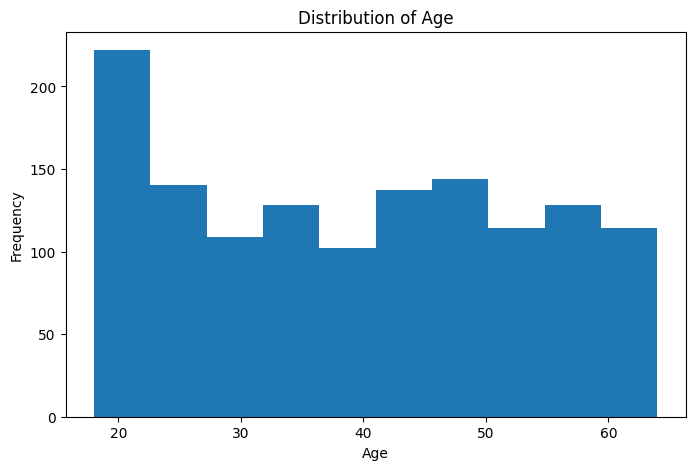

In [8]:
plt.figure(figsize=(8,5))

plt.hist(df['age'], bins=10)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")

plt.show()

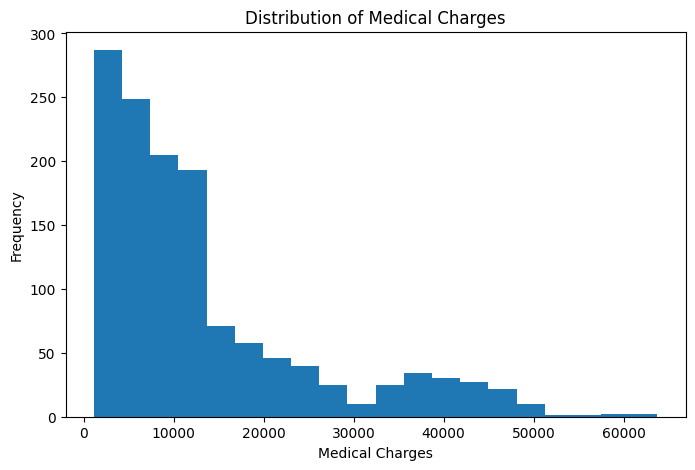

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df['charges'], bins=20)

plt.xlabel("Medical Charges")
plt.ylabel("Frequency")
plt.title("Distribution of Medical Charges")

plt.show()

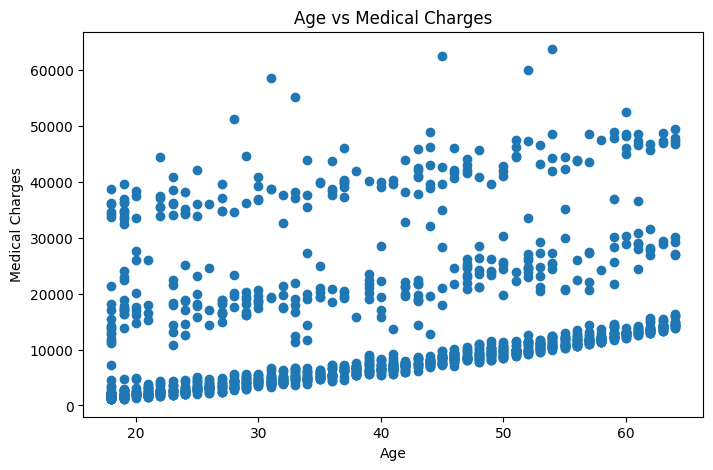

In [10]:
plt.figure(figsize=(8,5))

plt.scatter(df['age'], df['charges'])

plt.xlabel("Age")
plt.ylabel("Medical Charges")
plt.title("Age vs Medical Charges")

plt.show()

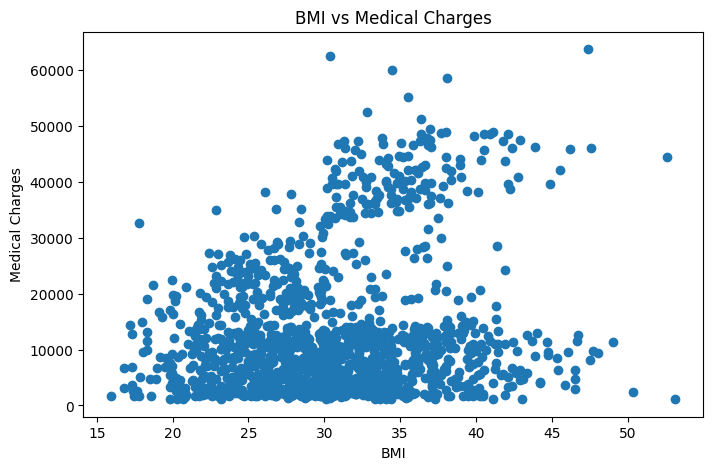

In [11]:
plt.figure(figsize=(8,5))

plt.scatter(df['bmi'], df['charges'])

plt.xlabel("BMI")
plt.ylabel("Medical Charges")
plt.title("BMI vs Medical Charges")

plt.show()

<Figure size 800x500 with 0 Axes>

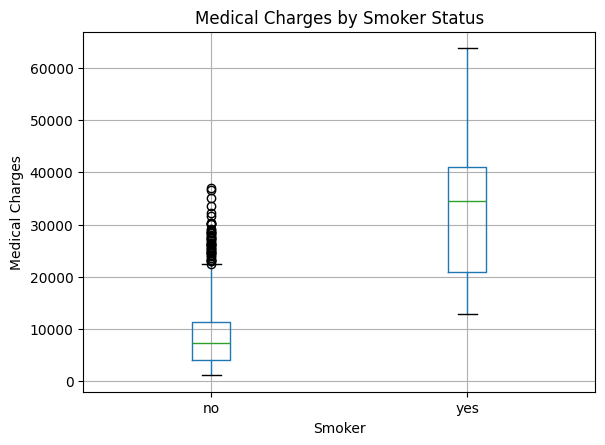

In [12]:
plt.figure(figsize=(8,5))

df.boxplot(column='charges', by='smoker')

plt.xlabel("Smoker")
plt.ylabel("Medical Charges")
plt.title("Medical Charges by Smoker Status")

plt.suptitle("")

plt.show()

In [13]:
correlation_df = df.copy()

correlation_df['sex'] = correlation_df['sex'].map({
    'male': 1,
    'female': 0
})

correlation_df['smoker'] = correlation_df['smoker'].map({
    'yes': 1,
    'no': 0
})

correlation_df['region'] = correlation_df['region'].map({
    'southwest': 0,
    'southeast': 1,
    'northwest': 2,
    'northeast': 3
})

correlation_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,0,16884.92400
1,18,1,33.770,1,0,1,1725.55230
2,28,1,33.000,3,0,1,4449.46200
3,33,1,22.705,0,0,2,21984.47061
4,32,1,28.880,0,0,2,3866.85520


In [14]:
correlation = correlation_df.corr()

print(correlation.round(2))

           age   sex   bmi  children  smoker  region  charges
age       1.00 -0.02  0.11      0.04   -0.03   -0.00     0.30
sex      -0.02  1.00  0.05      0.02    0.08   -0.00     0.06
bmi       0.11  0.05  1.00      0.01    0.00   -0.16     0.20
children  0.04  0.02  0.01      1.00    0.01   -0.02     0.07
smoker   -0.03  0.08  0.00      0.01    1.00    0.00     0.79
region   -0.00 -0.00 -0.16     -0.02    0.00    1.00     0.01
charges   0.30  0.06  0.20      0.07    0.79    0.01     1.00


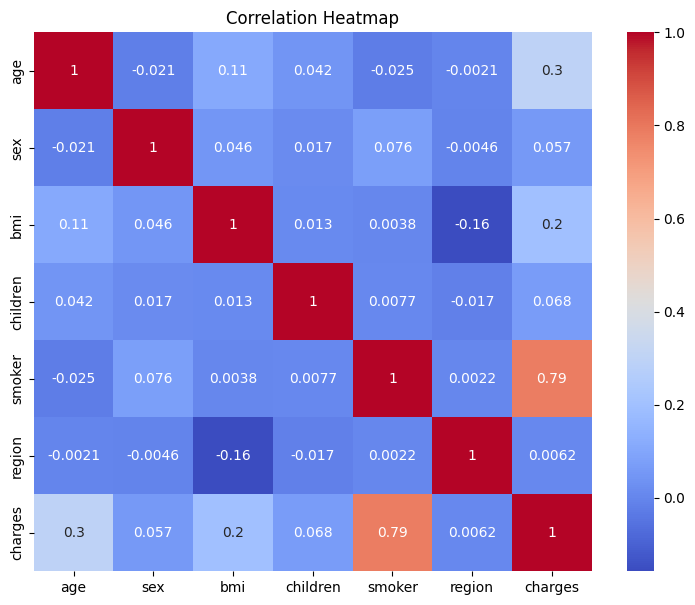

In [15]:
plt.figure(figsize=(9,7))

sns.heatmap(
    correlation_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [16]:
print(
    correlation_df.corr()['charges']
    .sort_values(ascending=False)
)

charges     1.000000
smoker      0.787251
age         0.299008
bmi         0.198341
children    0.067998
sex         0.057292
region      0.006208
Name: charges, dtype: float64


In [17]:
X = df[['age']]

y = df['charges']

print("Independent Variable")
print(X)

print("Dependent Variable")
print(y)

Independent Variable
      age
0      19
1      18
2      28
3      33
4      32
...   ...
1333   50
1334   18
1335   18
1336   21
1337   61

[1338 rows x 1 columns]
Dependent Variable
0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


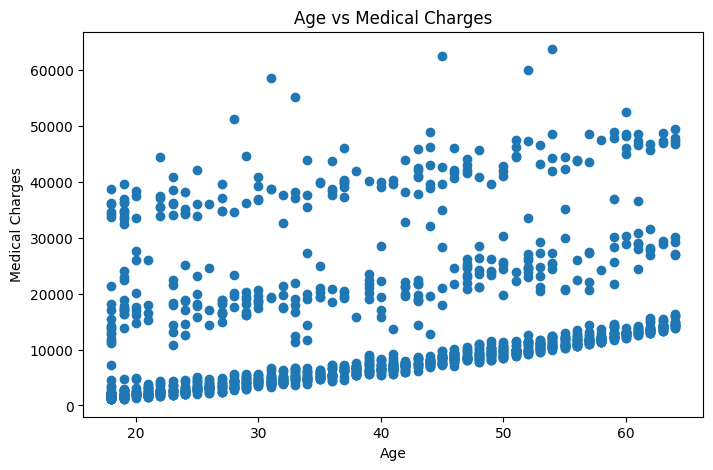

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(X, y)

plt.xlabel("Age")
plt.ylabel("Medical Charges")

plt.title("Age vs Medical Charges")

plt.show()

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1070
Testing samples: 268


In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:10])

[[ 0.47222651]
 [ 0.54331294]
 [ 0.8987451 ]
 [-0.02537852]
 [ 1.04091797]
 [ 1.68069586]
 [-1.23384787]
 [-1.5181936 ]
 [ 0.04570791]
 [-0.16755139]]


In [40]:
X = df[['age']]
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R2 Score:", r2_score(y_test, pred))

Slope: 240.59655978877493
Intercept: 3876.928684191691
R2 Score: 0.12408973539501944


In [41]:
print("Intercept:", linear_model.intercept_)

print("Slope:", linear_model.coef_[0])

print("Regression Equation")

print(
    "Charges =",
    round(linear_model.intercept_, 2),
    "+",
    round(linear_model.coef_[0], 2),
    "x Age"
)

Intercept: 13346.089736364485
Slope: 3384.563710858919
Regression Equation
Charges = 13346.09 + 3384.56 x Age


In [42]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train_scaled,
    y_train
)

ridge_pred = ridge_model.predict(
    X_test_scaled
)

print("Ridge Regression")
print("Alpha:", ridge_model.alpha)
print("Coefficient:", ridge_model.coef_[0])
print("Intercept:", ridge_model.intercept_)

Ridge Regression
Alpha: 1.0
Coefficient: 3381.4035206527024
Intercept: 13346.089736364485


In [43]:
lasso_model = Lasso(alpha=1.0)

lasso_model.fit(
    X_train_scaled,
    y_train
)

lasso_pred = lasso_model.predict(
    X_test_scaled
)

print("Lasso Regression")
print("Alpha:", lasso_model.alpha)
print("Coefficient:", lasso_model.coef_[0])
print("Intercept:", lasso_model.intercept_)

Lasso Regression
Alpha: 1.0
Coefficient: 3383.5637108589194
Intercept: 13346.089736364485


In [44]:
tree_model = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

tree_pred = tree_model.predict(
    X_test
)

print("Decision Tree Regression")
print("Max Depth:", tree_model.max_depth)

Decision Tree Regression
Max Depth: 3


In [45]:
forest_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=3,
    random_state=42
)

forest_model.fit(
    X_train,
    y_train
)

forest_pred = forest_model.predict(
    X_test
)

print("Random Forest Regression")
print("Number of Trees:", forest_model.n_estimators)
print("Max Depth:", forest_model.max_depth)

Random Forest Regression
Number of Trees: 100
Max Depth: 3


In [46]:
predictions = {
    'Linear Regression': linear_pred,
    'Ridge Regression': ridge_pred,
    'Lasso Regression': lasso_pred,
    'Decision Tree Regression': tree_pred,
    'Random Forest Regression': forest_pred
}

In [47]:
results = []

for model_name, prediction in predictions.items():

    mae = mean_absolute_error(
        y_test,
        prediction
    )

    mse = mean_squared_error(
        y_test,
        prediction
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        prediction
    )

    results.append([
        model_name,
        mae,
        mse,
        rmse,
        r2
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'MAE',
        'MSE',
        'RMSE',
        'R2'
    ]
)

print(results_df.round(2))

                      Model      MAE           MSE      RMSE    R2
0         Linear Regression  9173.26  1.359840e+08  11661.22  0.12
1          Ridge Regression  9173.59  1.359916e+08  11661.54  0.12
2          Lasso Regression  9173.36  1.359864e+08  11661.32  0.12
3  Decision Tree Regression  9142.85  1.359539e+08  11659.93  0.12
4  Random Forest Regression  9201.16  1.367166e+08  11692.59  0.12


In [48]:
comparison = pd.DataFrame({
    'Age': X_test['age'],
    'Actual': y_test,
    'Linear Regression': linear_pred,
    'Ridge Regression': ridge_pred,
    'Lasso Regression': lasso_pred,
    'Decision Tree Regression': tree_pred,
    'Random Forest Regression': forest_pred
})

comparison = comparison.sort_values(
    by='Age'
)

print(
    comparison.round(2).to_string(index=False)
)

 Age   Actual  Linear Regression  Ridge Regression  Lasso Regression  Decision Tree Regression  Random Forest Regression
  18  1131.51            8207.67           8212.46           8209.18                   9116.31                   8446.16
  18  2198.19            8207.67           8212.46           8209.18                   9116.31                   8446.16
  18  1708.93            8207.67           8212.46           8209.18                   9116.31                   8446.16
  18  1719.44            8207.67           8212.46           8209.18                   9116.31                   8446.16
  18  7323.73            8207.67           8212.46           8209.18                   9116.31                   8446.16
  18  1702.46            8207.67           8212.46           8209.18                   9116.31                   8446.16
  18  1727.54            8207.67           8212.46           8209.18                   9116.31                   8446.16
  18  1146.80            8207.67

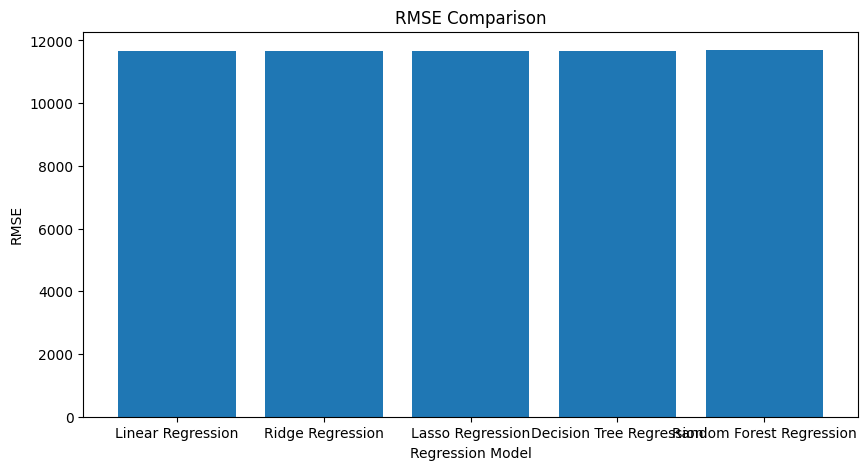

In [49]:
plt.figure(figsize=(10,5))

plt.bar(
    results_df['Model'],
    results_df['RMSE']
)

plt.xlabel("Regression Model")
plt.ylabel("RMSE")
plt.title("RMSE Comparison")

plt.show()

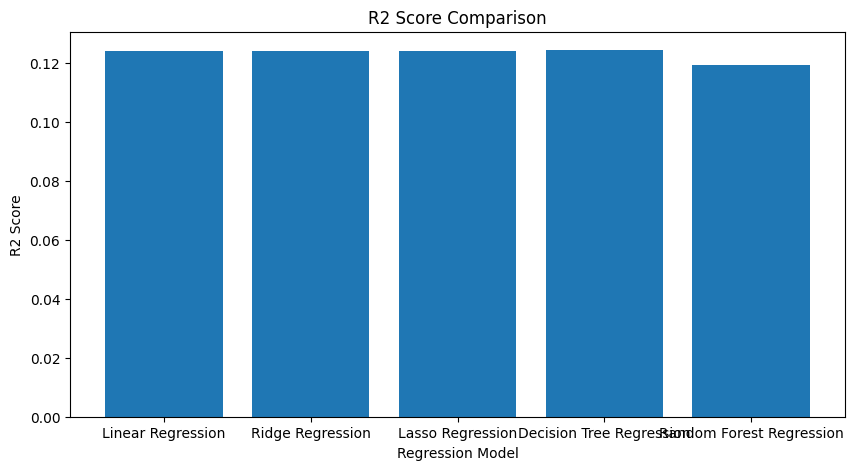

In [50]:
plt.figure(figsize=(10,5))

plt.bar(
    results_df['Model'],
    results_df['R2']
)

plt.xlabel("Regression Model")
plt.ylabel("R2 Score")
plt.title("R2 Score Comparison")

plt.show()

In [51]:
new_age = [[35]]

new_age_scaled = scaler.transform(
    new_age
)

new_linear = linear_model.predict(
    new_age_scaled
)[0]

new_ridge = ridge_model.predict(
    new_age_scaled
)[0]

new_lasso = lasso_model.predict(
    new_age_scaled
)[0]

new_tree = tree_model.predict(
    new_age
)[0]

new_forest = forest_model.predict(
    new_age
)[0]

prediction_result = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Decision Tree Regression',
        'Random Forest Regression'
    ],

    'Predicted Charges': [
        new_linear,
        new_ridge,
        new_lasso,
        new_tree,
        new_forest
    ]
})

print(
    prediction_result.round(2)
)

                      Model  Predicted Charges
0         Linear Regression           12297.81
1          Ridge Regression           12298.79
2          Lasso Regression           12298.12
3  Decision Tree Regression           12039.48
4  Random Forest Regression           11671.28


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [52]:
models = {
    'Linear Regression': linear_model,
    'Ridge Regression': ridge_model,
    'Lasso Regression': lasso_model,
    'Decision Tree Regression': tree_model,
    'Random Forest Regression': forest_model
}

best_model_name = results_df.loc[
    results_df['R2'].idxmax(),
    'Model'
]

best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Decision Tree Regression


In [53]:
import joblib

joblib.dump(
    best_model,
    "best_model.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Model saved successfully")

Model saved successfully


In [54]:
def predict_charges(age):

    sample_age = np.array([[age]])

    sample_age_scaled = scaler.transform(
        sample_age
    )

    prediction = model.predict(
        sample_age_scaled
    )

    return prediction[0]

In [55]:
model = joblib.load(
    "best_model.pkl"
)

scaler = joblib.load(
    "scaler.pkl"
)

print(
    "Predicted Charges:",
    predict_charges(35)
)

Predicted Charges: 9116.307450364964


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [58]:
import gradio as gr
import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.read_csv("insurance.csv")

X = df[["age"]]
y = df["charges"]

model = LinearRegression()
model.fit(X, y)

def predict_insurance(age):
    result = model.predict([[age]])
    return float(result[0])

demo = gr.Interface(
    fn=predict_insurance,
    inputs=gr.Number(label="Enter Age", value=20),
    outputs=gr.Number(label="Predicted Insurance Charges"),
    title="Medical Insurance Cost Prediction"
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1258457c6fc0b811e7.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
